# Proyecto de Análisis Eléctrico: Sensor Virtual de Estrés Térmico

**Etapa 1 y 2: Comprensión del problema y EDA básico**
El objetivo de este análisis es evaluar los datos operativos de los inversores solares, limpiarlos y construir un 'sensor virtual' (eficiencia de conversión DC/AC) que nos permita detectar sobrecalentamientos sin tener mediciones directas de temperatura.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Carga de datos (usamos 100,000 filas para el EDA)
file_path = 'data/2107_electrical_data.csv'
df = pd.read_csv(file_path, nrows=100000, parse_dates=['measured_on'])
print("Datos cargados correctamente.")


Datos cargados correctamente.


### 1. Exploración General (EDA Básico)
Antes de calcular nuestra eficiencia, debemos entender la calidad de nuestros datos: dimensiones, nulos y tipos.

In [3]:
# Dimensiones e información de tipos de datos
print("Dimensiones del dataset:", df.shape)
print("\n--- Tipos de datos (Muestra) ---")
df.info()


Dimensiones del dataset: (100000, 120)

--- Tipos de datos (Muestra) ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 120 entries, measured_on to inv_24_ac_power_inv_149698
dtypes: datetime64[us](1), float64(119)
memory usage: 91.6 MB


In [4]:
# Búsqueda de valores nulos
nulos_totales = df.isnull().sum().sum()
nulos_por_columna = df.isnull().sum()

print(f"Total de valores nulos en el dataset: {nulos_totales}")
if nulos_totales > 0:
    print("\nTop columnas con nulos:")
    print(nulos_por_columna[nulos_por_columna > 0].head())


Total de valores nulos en el dataset: 0


In [5]:
# Estadísticas descriptivas de un subconjunto (Ej. Inversor 01)
inv1_cols_raw = [col for col in df.columns if 'inv_01' in col]
df[inv1_cols_raw].describe().T


,count,mean,std,min,25%,50%,75%,max
inv_01_dc_current_inv_149579,100000.0,8.533811,13.367426,0.0,0.0,0.0,13.76950,48.657
inv_01_dc_voltage_inv_149580,100000.0,321.427183,334.631117,0.0,0.0,0.0,674.26000,909.840
inv_01_ac_current_inv_149581,100000.0,6.573405,9.997256,0.0,0.0,0.0,11.16500,35.410
inv_01_ac_voltage_inv_149582,100000.0,141.400279,143.860576,0.0,0.0,0.0,287.10300,310.677
inv_01_ac_power_inv_149583,100000.0,5.565993,8.629645,0.0,0.0,0.0,9.43225,30.021


### 2. Preparación e Ingeniería de Características
Aislaremos el **Inversor 01** como nuestro caso de estudio inicial. Calcularemos la potencia de entrada (DC) y definiremos la Eficiencia. *Nota: La potencia AC viene en kW, por lo que multiplicaremos por 1000.*

In [6]:
# Seleccionamos variables críticas del inversor 01
inv1_cols = [
    'measured_on',
    'inv_01_dc_current_inv_149579', 
    'inv_01_dc_voltage_inv_149580',
    'inv_01_ac_power_inv_149583'
]
df_inv1 = df[inv1_cols].copy()

# Renombramos para facilitar el análisis
df_inv1.columns = ['datetime', 'dc_current', 'dc_voltage', 'ac_power']
df_inv1.head()


,datetime,dc_current,dc_voltage,ac_power
0,2017-11-01 00:00:00,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0


In [7]:
# Potencia DC (W) = Corriente * Voltaje
df_inv1['dc_power'] = df_inv1['dc_current'] * df_inv1['dc_voltage']

# Filtramos la noche o apagones (donde no hay generación real)
df_inv1 = df_inv1[df_inv1['dc_power'] > 10].copy()

# Cálculo de Eficiencia (%)
# Multiplicamos ac_power por 1000 porque está medido en kW, mientras que dc_power está en W
df_inv1['efficiency'] = ((df_inv1['ac_power'] * 1000) / df_inv1['dc_power']) * 100

print("Estadísticas de nuestra nueva variable 'Eficiencia':")
print(df_inv1['efficiency'].describe())


Estadísticas de nuestra nueva variable 'Eficiencia':
count    46557.000000
mean        90.175247
std         22.513108
min          0.000000
25%         96.210947
50%         97.524581
75%         98.171646
max        611.928671
Name: efficiency, dtype: float64


### 3. Visualización Bivariada (Tendencia temporal)
Vamos a graficar la curva de eficiencia durante los primeros días para buscar esas 'caídas térmicas' al medio día.

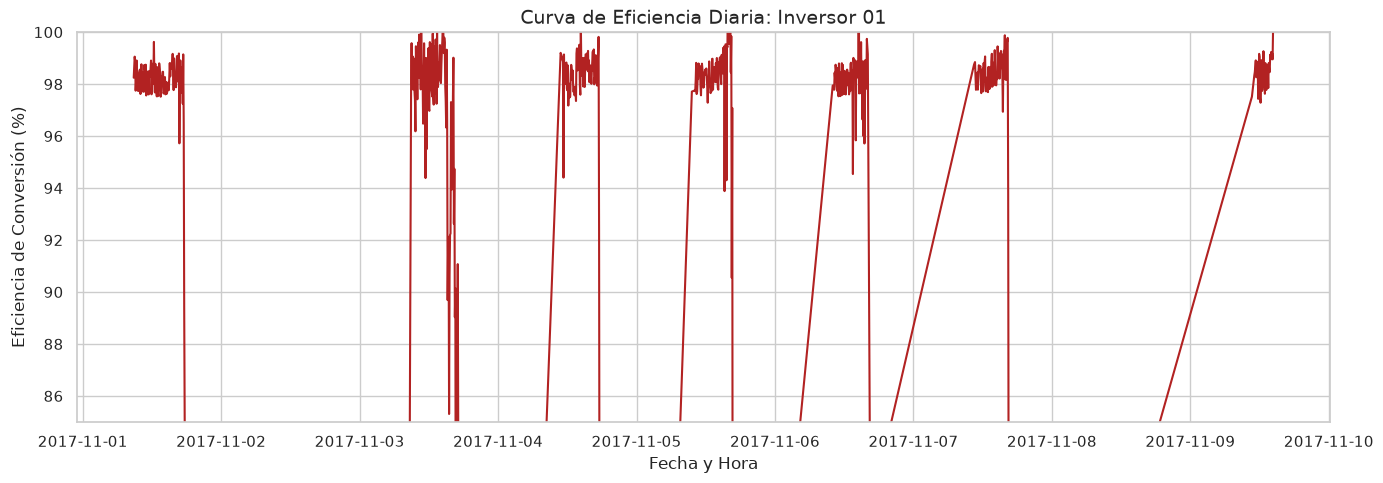

In [8]:
# Graficamos los primeros 2-3 días operativos (12 observaciones por hora aprox = 288 mediciones por día)
# Seleccionamos una ventana de datos para claridad visual
ventana_visual = df_inv1.head(288 * 2)

plt.figure(figsize=(14, 5))
sns.lineplot(data=ventana_visual, x='datetime', y='efficiency', color='firebrick')

plt.title('Curva de Eficiencia Diaria: Inversor 01', fontsize=14)
plt.ylabel('Eficiencia de Conversión (%)', fontsize=12)
plt.xlabel('Fecha y Hora', fontsize=12)

# Limitamos el eje Y para ver mejor los detalles entre el 90% y 100% (omitiendo arranques erráticos)
plt.ylim(85, 100) 
plt.tight_layout()
plt.show()


## Etapa 3: Preparación de Datos a Escala (24 Inversores)
**Objetivo del paso:** Extrapolar nuestra lógica de limpieza a todos los inversores, tratar los valores nulos/atípicos (outliers) y guardar las visualizaciones como evidencia.

In [9]:
import os

# Crear directorio para guardar nuestras evidencias visuales
evidencias_dir = 'evidencias'
os.makedirs(evidencias_dir, exist_ok=True)
print(f"Directorio '{evidencias_dir}' listo para guardar gráficos.")


Directorio 'evidencias' listo para guardar gráficos.


In [10]:
# Iteramos sobre los 24 inversores para extraer y limpiar su eficiencia
eficiencias = {}
inversores_con_error = []

for i in range(1, 25):
    idx = f"{i:02d}"
    cols = [col for col in df.columns if f'inv_{idx}' in col]
    
    if len(cols) > 0:
        try:
            dc_curr = [c for c in cols if 'dc_current' in c][0]
            dc_volt = [c for c in cols if 'dc_voltage' in c][0]
            ac_pow = [c for c in cols if 'ac_power' in c][0]
            
            # Calcular DC Power
            dc_power = df[dc_curr] * df[dc_volt]
            mask_active = dc_power > 10
            
            # Calcular eficiencia vectorizada solo para momentos activos
            eff = ((df.loc[mask_active, ac_pow] * 1000) / dc_power.loc[mask_active]) * 100
            
            # Tratamiento de Outliers (clip)
            eff_limpia = np.clip(eff, a_min=0, a_max=100)
            eficiencias[f'Inv_{idx}'] = eff_limpia
            
        except IndexError:
            # Si falta alguna de las 3 columnas vitales, registramos el error y saltamos
            inversores_con_error.append(idx)

# Convertir a DataFrame consolidado
df_eff = pd.DataFrame(eficiencias)
print("Dimensiones del panel de eficiencias:", df_eff.shape)
if inversores_con_error:
    print(f"\n¡ALERTA! Los siguientes inversores no tienen datos completos y fueron omitidos: {inversores_con_error}")


Dimensiones del panel de eficiencias: (51442, 23)

¡ALERTA! Los siguientes inversores no tienen datos completos y fueron omitidos: ['05']


### Detección de anomalías a nivel granja
Usaremos un diagrama de caja (Boxplot) para comparar el rendimiento mediano de todos los inversores y detectar rápidamente cuáles están sub-rindiendo.

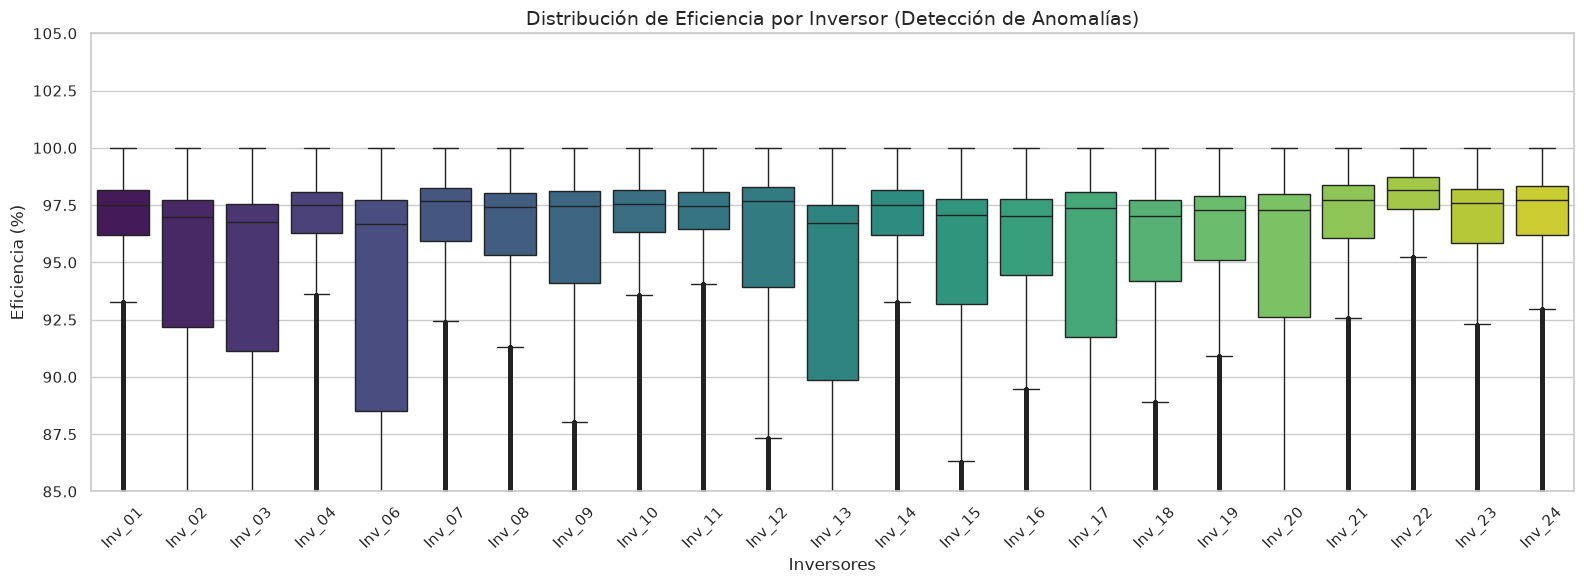

Evidencia guardada exitosamente en: evidencias/01_boxplot_eficiencia.png


In [11]:
plt.figure(figsize=(16, 6))
# Boxplot ideal para comparar múltiples distribuciones y ver sus outliers
sns.boxplot(data=df_eff, palette="viridis", fliersize=2)

plt.title('Distribución de Eficiencia por Inversor (Detección de Anomalías)', fontsize=14)
plt.ylabel('Eficiencia (%)')
plt.xlabel('Inversores')
plt.xticks(rotation=45)
plt.ylim(85, 105) 
plt.tight_layout()

# Guardar evidencia
ruta_evidencia = os.path.join(evidencias_dir, '01_boxplot_eficiencia.png')
plt.savefig(ruta_evidencia, dpi=300)
plt.show()

print(f"Evidencia guardada exitosamente en: {ruta_evidencia}")


### Respaldo Cuantitativo (Tabla de Eficiencias)
Para evitar la ambigüedad visual que a veces tienen los gráficos (como el Boxplot), siempre es una buena práctica respaldar nuestros hallazgos con métricas duras (tablas). A continuación calcularemos la mediana de eficiencia de cada inversor y la ordenaremos de peor a mejor.

In [12]:
# Calculamos la mediana (para evitar que picos extremos distorsionen la métrica como pasaría con la media)
tabla_eficiencia = df_eff.median().reset_index()
tabla_eficiencia.columns = ['Inversor', 'Mediana_Eficiencia_PCT']

# Ordenamos de menor a mayor eficiencia
tabla_eficiencia = tabla_eficiencia.sort_values(by='Mediana_Eficiencia_PCT')

# Mostramos los 5 peores y los 5 mejores
print("--- LOS 5 INVERSORES CON PEOR RENDIMIENTO ---")
display(tabla_eficiencia.head())

print("\n--- LOS 5 INVERSORES CON MEJOR RENDIMIENTO ---")
display(tabla_eficiencia.tail())

# Exportar tabla como evidencia de texto (.csv)
ruta_csv = os.path.join(evidencias_dir, '02_tabla_eficiencia_mediana.csv')
tabla_eficiencia.to_csv(ruta_csv, index=False)
print(f"\nEvidencia tabular guardada en: {ruta_csv}")


--- LOS 5 INVERSORES CON PEOR RENDIMIENTO ---


,Inversor,Mediana_Eficiencia_PCT
4,Inv_06,96.680315
11,Inv_13,96.703038
2,Inv_03,96.781722
1,Inv_02,96.979709
16,Inv_18,97.026667



--- LOS 5 INVERSORES CON MEJOR RENDIMIENTO ---


,Inversor,Mediana_Eficiencia_PCT
10,Inv_12,97.660620
5,Inv_07,97.671878
22,Inv_24,97.702887
19,Inv_21,97.744172
20,Inv_22,98.152082



Evidencia tabular guardada en: evidencias/02_tabla_eficiencia_mediana.csv


## Etapa 4: Modelado - Aprendizaje No Supervisado
**Objetivo del paso:** Agrupar (clusterizar) a los inversores automáticamente usando un algoritmo de Machine Learning, buscando identificar a los que muestran síntomas de estrés térmico (baja eficiencia + alta volatilidad).

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Creamos nuestra matriz de características (Features)
# Feature 1: Mediana (Rendimiento habitual)
# Feature 2: Desviación Estándar (Volatilidad, que delata las caídas térmicas abruptas al mediodía)
features = pd.DataFrame({
    'Inversor': df_eff.columns,
    'Mediana': df_eff.median().values,
    'Volatilidad_STD': df_eff.std().values
})

# 2. Escalado de datos: Crucial en ML para que la mediana no "pese" más que la volatilidad por estar en escalas diferentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[['Mediana', 'Volatilidad_STD']])
print("Características listas y escaladas.")


Características listas y escaladas.


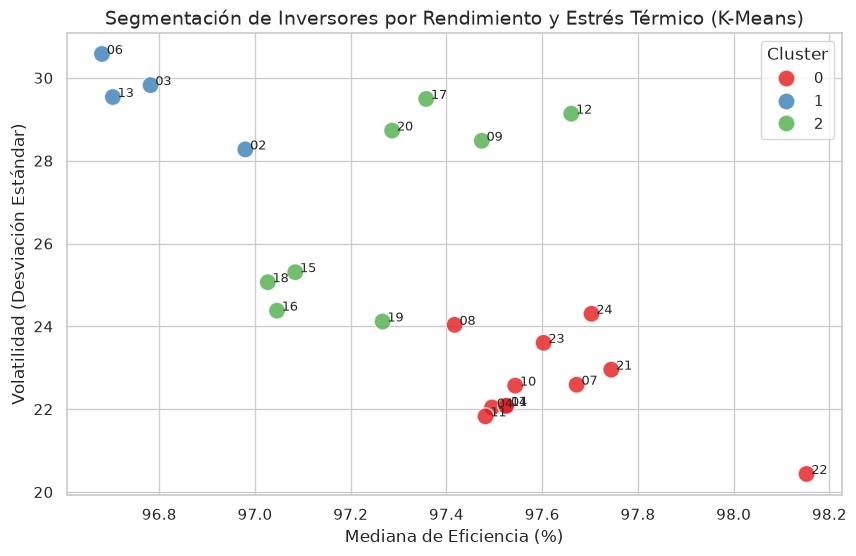


Evidencia de clusterización guardada en: evidencias/03_kmeans_clusters.png


,Inversor,Mediana,Volatilidad_STD,Cluster
6,Inv_08,97.416982,24.037479,0
9,Inv_11,97.481530,21.827283,0
3,Inv_04,97.495121,22.041980,0
0,Inv_01,97.524581,22.080932,0
12,Inv_14,97.524581,22.080932,0
8,Inv_10,97.543543,22.569361,0
21,Inv_23,97.602793,23.603532,0
5,Inv_07,97.671878,22.591707,0
22,Inv_24,97.702887,24.304638,0
19,Inv_21,97.744172,22.955243,0


In [14]:
# 3. Entrenamos un modelo K-Means para que encuentre 3 grupos (ej. Óptimo, Aceptable, Crítico)
# Usamos random_state para reproducibilidad
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualización de los Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=features, 
    x='Mediana', 
    y='Volatilidad_STD', 
    hue='Cluster', 
    palette='Set1',
    s=150, 
    alpha=0.8
)

# Etiquetamos los puntos para saber quién es quién
for i in range(features.shape[0]):
    plt.text(features['Mediana'][i] + 0.01, features['Volatilidad_STD'][i], 
             features['Inversor'][i].split('_')[1], 
             fontsize=9)

plt.title('Segmentación de Inversores por Rendimiento y Estrés Térmico (K-Means)', fontsize=14)
plt.xlabel('Mediana de Eficiencia (%)')
plt.ylabel('Volatilidad (Desviación Estándar)')

# Guardamos evidencia
ruta_cluster = os.path.join(evidencias_dir, '03_kmeans_clusters.png')
plt.savefig(ruta_cluster, dpi=300)
plt.show()

print(f"\nEvidencia de clusterización guardada en: {ruta_cluster}")
display(features.sort_values(by=['Cluster', 'Mediana']))


### Modelado Supervisado (Regresión)
**Objetivo:** Crear un modelo predictivo capaz de estimar la potencia de salida (`ac_power`) basándose en las variables de entrada (`dc_current`, `dc_voltage`). Usaremos el Inversor 22 (nuestro inversor óptimo) como estándar de oro.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparar datos del Inversor 22 (El mejor del grupo)
# Filtramos datos activos
mask_inv22 = (df['inv_22_dc_current_inv_149684'] * df['inv_22_dc_voltage_inv_149685']) > 10
df_ml = df[mask_inv22].copy()

X = df_ml[['inv_22_dc_current_inv_149684', 'inv_22_dc_voltage_inv_149685']]
y = df_ml['inv_22_ac_power_inv_149688']

# 2. División Entrenamiento / Prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamiento (Aprendizaje Supervisado)
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# 4. Predicción y Evaluación
predicciones = modelo_regresion.predict(X_test)
r2 = r2_score(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"Rendimiento del Modelo Supervisado (Inversor 22):")
print(f"R² (Precisión): {r2*100:.2f}%")
print(f"Error RMSE: {rmse:.3f} kW")


Rendimiento del Modelo Supervisado (Inversor 22):
R² (Precisión): 99.18%
Error RMSE: 0.933 kW


#### Evidencia Visual: Regresión (Real vs Predicho)

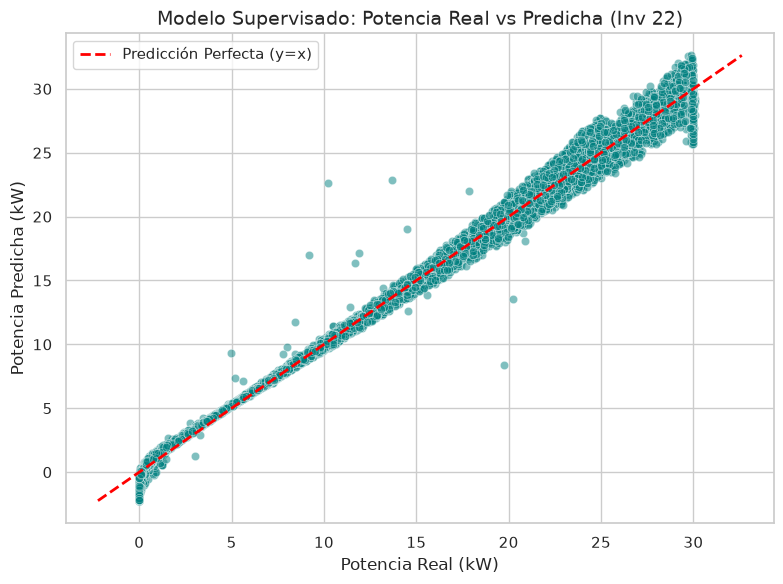

Evidencia del modelo supervisado guardada en: evidencias/05_supervisado_real_vs_pred.png


In [16]:
plt.figure(figsize=(8, 6))
# Gráfico de dispersión: Eje X = Lo real, Eje Y = Lo predicho
sns.scatterplot(x=y_test, y=predicciones, alpha=0.5, color='teal')

# Añadimos la línea ideal perfecta (y = x)
max_val = max(y_test.max(), predicciones.max())
min_val = min(y_test.min(), predicciones.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title('Modelo Supervisado: Potencia Real vs Predicha (Inv 22)', fontsize=14)
plt.xlabel('Potencia Real (kW)')
plt.ylabel('Potencia Predicha (kW)')
plt.legend()
plt.tight_layout()

ruta_supervisado = os.path.join(evidencias_dir, '05_supervisado_real_vs_pred.png')
plt.savefig(ruta_supervisado, dpi=300)
plt.show()

print(f"Evidencia del modelo supervisado guardada en: {ruta_supervisado}")


### Modelado Forecasting (Series de Tiempo)
**Objetivo:** Predecir la generación futura de energía de toda la planta eléctrica usando datos históricos (rezagos/lags).

/tmp/ipykernel_109855/1003067082.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_ac_power'] = df[cols_ac].fillna(0).sum(axis=1)


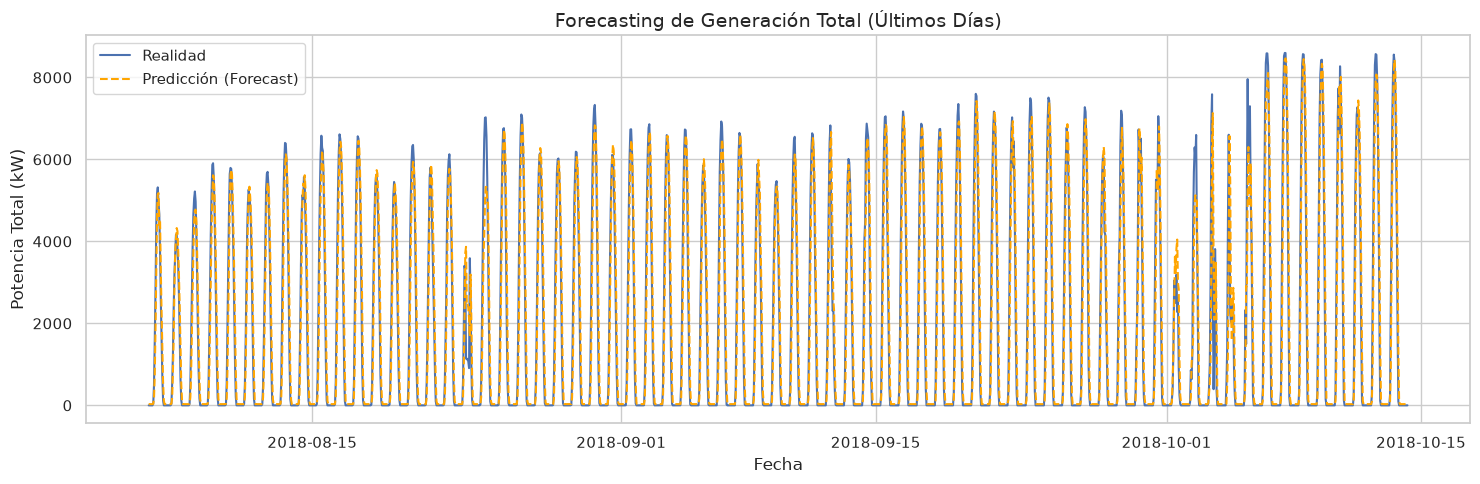

Evidencia de forecasting guardada en: evidencias/04_forecasting.png


In [17]:
# 1. Agrupar la potencia AC total por hora
cols_ac = [c for c in df.columns if 'ac_power' in c]
# Llenamos nulos con 0 por si algún inversor falló temporalmente
df['total_ac_power'] = df[cols_ac].fillna(0).sum(axis=1)

# Creamos un dataframe temporal agrupado por horas (Resampling)
df_time = df[['measured_on', 'total_ac_power']].copy()
df_time.set_index('measured_on', inplace=True)
df_horario = df_time.resample('1h').sum()

# 2. Ingeniería de Features Temporales (Lags)
# Creamos variables "rezagadas": ¿Cuánta energía hubo hace 1, 2 y 24 horas?
df_horario['lag_1h'] = df_horario['total_ac_power'].shift(1)
df_horario['lag_24h'] = df_horario['total_ac_power'].shift(24) # Mismo momento, ayer

# Eliminamos las primeras 24 horas que ahora tienen valores nulos por el shift
df_horario.dropna(inplace=True)

# 3. Entrenamiento del Forecasting (usando los primeros días para entrenar y los últimos para predecir)
X_ts = df_horario[['lag_1h', 'lag_24h']]
y_ts = df_horario['total_ac_power']

# Separación cronológica (NO aleatoria)
split_idx = int(len(df_horario) * 0.8)
X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

# Modelo
modelo_ts = LinearRegression()
modelo_ts.fit(X_train_ts, y_train_ts)
df_horario.loc[X_test_ts.index, 'Prediccion_Forecasting'] = modelo_ts.predict(X_test_ts)

# 4. Visualización del Forecasting
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_horario.iloc[split_idx:], x=df_horario.iloc[split_idx:].index, y='total_ac_power', label='Realidad')
sns.lineplot(data=df_horario.iloc[split_idx:], x=df_horario.iloc[split_idx:].index, y='Prediccion_Forecasting', color='orange', linestyle='--', label='Predicción (Forecast)')

plt.title('Forecasting de Generación Total (Últimos Días)', fontsize=14)
plt.ylabel('Potencia Total (kW)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()

ruta_forecasting = os.path.join(evidencias_dir, '04_forecasting.png')
plt.savefig(ruta_forecasting, dpi=300)
plt.show()

print(f"Evidencia de forecasting guardada en: {ruta_forecasting}")


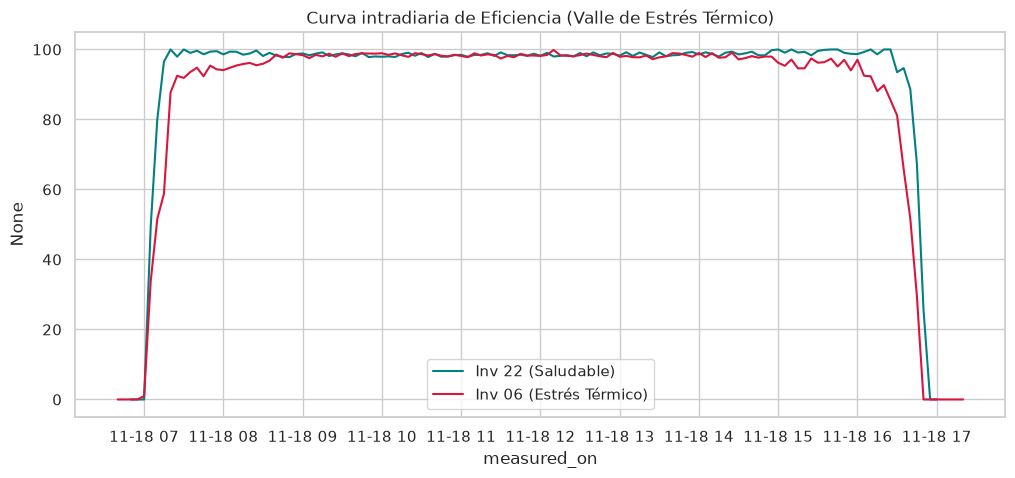

In [19]:
# NUEVA EVIDENCIA EDA: Curva temporal de estrés térmico
# Comparamos el mejor y el peor inversor a lo largo de un día
df_day = df[df['measured_on'].dt.date == df['measured_on'].dt.date.iloc[5000]].copy()
plt.figure(figsize=(12, 5))

# Usamos .reindex() para rellenar con NaNs las horas nocturnas y evitar KeyError
eff_22 = eficiencias['Inv_22'].reindex(df_day.index)
eff_06 = eficiencias.get('Inv_06', pd.Series(dtype=float)).reindex(df_day.index)

sns.lineplot(data=df_day, x='measured_on', y=eff_22, label='Inv 22 (Saludable)', color='teal')
sns.lineplot(data=df_day, x='measured_on', y=eff_06, label='Inv 06 (Estrés Térmico)', color='crimson')
plt.title('Curva intradiaria de Eficiencia (Valle de Estrés Térmico)')
plt.show()